In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from datetime import datetime

In [57]:
file_path = 'UST Data Sample (July - Sept 2024).xlsx'
df = pd.read_excel(file_path)
df

,let me tak,Id,Client,RFQStatus,InstrumentSubGroup,Market Traded Vol (USD),Our Traded Vol,TiedWonVol,Num of Dealers,Trader,...,SettlementDays,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket
0,2024-09-30,66FA7D45432800D20002,Client1,Done,OFFTHERUN,100000000,100000000,100000000,6,Trader1,...,1,2024-10-01,T+1,2024-09-30 06:28:00,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y
1,2024-09-30,TRSY_20240930_15961,Client2,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,5,Trader2,...,1,2024-10-01,T+1,2024-09-30 16:00:00,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y
2,2024-09-30,TRSY_20240930_314,Client2,Done,ONTHERUN,53000000,53000000,53000000,5,Trader3,...,1,2024-10-01,T+1,2024-09-30 15:46:00,2024-09-30 15:46:00,1,0.07,50+M,7-10 YR,7y-10y
3,2024-09-30,66FAEA57432800020001,Client3,Done,OFFTHERUN,500000,500000,500000,5,Trader4,...,1,2024-10-01,T+1,2024-09-30 14:14:00,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos
4,2024-09-30,66FAC35D455C00210006,Client4,Done,OFFTHERUN,1058000,1058000,1058000,5,Trader2,...,1,2024-10-01,T+1,2024-09-30 11:27:00,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66676,2024-07-01,E68302E5454C00010001,Client33,CustomerTimeOut,ONTHERUN,0,0,0,1,Trader4,...,1,2024-07-02,T+1,2024-07-01 15:26:00,2024-07-01 15:27:00,1,0.04,1-5M,BILLS,<18mos
66677,2024-07-01,E68305CA57D000080001,Client33,CustomerTimeOut,ONTHERUN,0,0,0,1,Trader4,...,1,2024-07-02,T+1,2024-07-01 15:38:00,2024-07-01 15:40:00,1,0.04,1-5M,BILLS,<18mos
66678,2024-07-01,E683099657D000010001,Client33,CustomerTimeOut,ONTHERUN,0,0,0,1,Trader4,...,1,2024-07-02,T+1,2024-07-01 15:55:00,2024-07-01 15:56:00,1,0.04,1-5M,BILLS,<18mos
66679,2024-07-01,6682BE1857D0000C0002,Client271,CustomerTimeOut,OFFTHERUN,0,0,0,15,Trader4,...,1,2024-07-02,T+1,2024-07-01 10:33:00,2024-07-01 10:34:00,0,4.99,10-25M,0-1 YR,<18mos


In [58]:
# Modify the year < 2000
df['Maturity Date'] = df['Maturity Date'].apply(lambda x: x if x.year >= 2000 else x.replace(year=x.year + 100))
df['Maturity Date'].unique()

<DatetimeArray>
['2030-04-30 00:00:00', '2034-02-15 00:00:00', '2031-09-30 00:00:00',
 '2025-09-15 00:00:00', '2028-06-30 00:00:00', '2024-10-29 00:00:00',
 '2029-09-30 00:00:00', '2027-09-15 00:00:00', '2034-08-15 00:00:00',
 '2044-08-15 00:00:00',
 ...
 '2034-11-15 00:00:00', '2024-07-23 00:00:00', '2024-07-18 00:00:00',
 '2037-08-15 00:00:00', '2024-07-16 00:00:00', '2024-07-15 00:00:00',
 '2024-07-11 00:00:00', '2024-07-09 00:00:00', '2024-07-05 00:00:00',
 '2024-07-02 00:00:00']
Length: 319, dtype: datetime64[ns]

In [59]:
missing_values = df.isnull().sum()
missing_values

let me tak                     0
Id                             0
Client                         0
RFQStatus                      0
InstrumentSubGroup             0
Market Traded Vol (USD)        0
Our Traded Vol                 0
TiedWonVol                     0
Num of Dealers                 0
Trader                         0
Sales                          0
Covered Vol                    0
ActionStr                      0
Tier                           0
InstrumentCode                 0
InstrumentDescription          0
AssetClass                     0
Market                         0
LegNo                          0
Maturity Date                  0
RFQNumberOfQuotes              0
Buy/Sell                       0
Best Bid Price                 0
Mid Price                      0
Best Ask Price                 0
Deal Value                     0
AwayFromMid                    0
TickIdentifier               445
Deal Spread                    0
Cover                          0
CoverPnL  

In [60]:
df.dropna(inplace=True)

In [61]:
df = df[df['AssetClass'] != 'TFRNS']

In [62]:
# Function to calculate years to maturity
def calculate_years_to_maturity(row):
    maturity_date = pd.to_datetime(row['Maturity Date'])
    trade_date = pd.to_datetime(row['let me tak'])
    return (maturity_date - trade_date).days / 365.25

df['Years to Maturity'] = df.apply(calculate_years_to_maturity, axis=1)


def extract_yield(description):
    match = re.search(r"(\d+\.\d+)", description)
    return float(match.group(1)) if match else np.nan  # Return NaN if no match is found

df['Yield'] = df['InstrumentDescription'].apply(extract_yield)

def yield_to_price(ytm, years_to_maturity, face_value=100):
    if pd.isna(ytm) or pd.isna(years_to_maturity):
        return np.nan
    return face_value / ((1 + 0.01 * ytm) ** years_to_maturity)

def bill_price(face_value, deal_price, days_to_maturity):
    if pd.isna(deal_price) or pd.isna(days_to_maturity):
        return np.nan
    discount_yield = ((face_value - deal_price) / face_value) * (360 / days_to_maturity)
    return face_value * (1 - (discount_yield / 100) * (days_to_maturity / 360))

# Columns to convert
columns_to_convert = ['Best Bid Price', 'Mid Price', 'Best Ask Price', 'Deal Value', 'Cover']

for column in columns_to_convert:
    df[f'Converted {column}'] = df.apply(
        lambda row: (
            # yield_to_price(row['Yield'], row['Years to Maturity']) if row['AssetClass'] == 'STRIPS'
            # else (
                bill_price(100, row[column], (pd.to_datetime(row['Maturity Date']) - pd.to_datetime(row['let me tak'])).days)
                if (row['AssetClass'] == 'BILLS' or row['AssetClass'] == 'STRIPS')else row[column]
            # )
        ),
        axis=1
    )

print(df[['InstrumentDescription', 'AssetClass', 'Yield', 'Years to Maturity'] + [f'Converted {col}' for col in columns_to_convert]])

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_63523/1194386698.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Years to Maturity'] = df.apply(calculate_years_to_maturity, axis=1)
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_63523/1194386698.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Yield'] = df['InstrumentDescription'].apply(extract_yield)
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_63523/1194386698.py:31: SettingWithCopyWarning: 
A value is t

        InstrumentDescription AssetClass  Yield  Years to Maturity  \
0           T  3.500 04/30/30      BONDS  3.500           5.579740   
1           T  4.000 02/15/34      BONDS  4.000           9.377139   
2      T  3.625 09/30/31  7YR      BONDS  3.625           6.997947   
3           T  3.500 09/15/25      BONDS  3.500           0.958248   
4           T  4.000 06/30/28      BONDS  4.000           3.748118   
...                       ...        ...    ...                ...   
66676        B  09/26/24  3MO      BILLS    NaN           0.238193   
66677        B  09/26/24  3MO      BILLS    NaN           0.238193   
66678        B  09/26/24  3MO      BILLS    NaN           0.238193   
66679       T  1.000 12/15/24      BONDS  1.000           0.457221   
66680             B  07/02/24      BILLS    NaN           0.002738   

       Converted Best Bid Price  Converted Mid Price  \
0                     99.539062            99.550781   
1                    101.712388           101.7

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_63523/1194386698.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'Converted {column}'] = df.apply(


In [63]:
# Filter the DataFrame for AssetClass that is either BILLS or STRIPS
bills_strips_df = df[df['AssetClass'].isin(['BILLS', 'STRIPS', 'BONDS'])]

# Select only the columns that are related to converted prices
columns_to_display = ['InstrumentDescription', 'AssetClass', 'Yield', 'Years to Maturity'] + [f'Converted {col}' for col in columns_to_convert]

# Display the filtered DataFrame with the desired columns
print(bills_strips_df[columns_to_display].head(30))

      InstrumentDescription AssetClass  Yield  Years to Maturity  \
0         T  3.500 04/30/30      BONDS  3.500           5.579740   
1         T  4.000 02/15/34      BONDS  4.000           9.377139   
2    T  3.625 09/30/31  7YR      BONDS  3.625           6.997947   
3         T  3.500 09/15/25      BONDS  3.500           0.958248   
4         T  4.000 06/30/28      BONDS  4.000           3.748118   
5          B  10/29/24  1MO      BILLS    NaN           0.079398   
6    T  3.500 09/30/29  5YR      BONDS  3.500           4.999316   
7    T  3.625 09/30/31  7YR      BONDS  3.625           6.997947   
8    T  3.375 09/15/27  3YR      BONDS  3.375           2.956879   
9   T  3.875 08/15/34  10YR      BONDS  3.875           9.872690   
10   T  3.500 09/30/29  5YR      BONDS  3.500           4.999316   
11  T  4.125 08/15/44  20YR      BONDS  4.125          19.874059   
12  T  3.875 08/15/34  10YR      BONDS  3.875           9.872690   
13  T  4.250 08/15/54  30YR      BONDS  4.250   

In [64]:
df['Spread'] = df['Converted Best Ask Price'] - df['Converted Best Bid Price']

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_63523/573616645.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Spread'] = df['Converted Best Ask Price'] - df['Converted Best Bid Price']


## slippage

In [65]:
def calculate_slippage_price(row):
    if row['Buy/Sell'] == 'Buy':
        return (row['Converted Deal Value'] - row['Converted Mid Price'])
    elif row['Buy/Sell'] == 'Sell':
        return (row['Converted Mid Price'] - row['Converted Deal Value'])
    return None

df['Slippage'] = df.apply(calculate_slippage_price, axis=1)

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_63523/1307256940.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Slippage'] = df.apply(calculate_slippage_price, axis=1)


# VPIN

## Volume Bucketing

In [85]:
import copy
df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})
df

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_63523/3682741170.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})
/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_63523/3682741170.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})


,let me tak,Id,Client,RFQStatus,InstrumentSubGroup,Market Traded Vol (USD),Our Traded Vol,TiedWonVol,Num of Dealers,Trader,...,Years to Maturity,Yield,Converted Best Bid Price,Converted Mid Price,Converted Best Ask Price,Converted Deal Value,Converted Cover,Spread,Slippage,Sign
0,2024-09-30,66FA7D45432800D20002,Client1,Done,OFFTHERUN,100000000,100000000,100000000,6,Trader1,...,5.579740,3.500,99.539062,99.550781,99.562500,99.558594,99.558594,0.023438,-0.007812,-1
1,2024-09-30,TRSY_20240930_15961,Client2,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,5,Trader2,...,9.377139,4.000,101.712388,101.724107,101.735826,101.726562,101.726562,0.023438,-0.002456,-1
2,2024-09-30,TRSY_20240930_314,Client2,Done,ONTHERUN,53000000,53000000,53000000,5,Trader3,...,6.997947,3.625,99.761719,99.765625,99.769531,99.761719,99.761719,0.007812,0.003906,-1
3,2024-09-30,66FAEA57432800020001,Client3,Done,OFFTHERUN,500000,500000,500000,5,Trader4,...,0.958248,3.500,99.535156,99.539062,99.542969,99.554688,99.554688,0.007812,-0.015625,-1
4,2024-09-30,66FAC35D455C00210006,Client4,Done,OFFTHERUN,1058000,1058000,1058000,5,Trader2,...,3.748118,4.000,101.601562,101.609375,101.617188,101.605469,101.605469,0.015625,-0.003906,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66676,2024-07-01,E68302E5454C00010001,Client33,CustomerTimeOut,ONTHERUN,0,0,0,1,Trader4,...,0.238193,NaN,99.052250,99.052225,99.052200,99.052175,99.000000,-0.000050,0.000050,-1
66677,2024-07-01,E68305CA57D000080001,Client33,CustomerTimeOut,ONTHERUN,0,0,0,1,Trader4,...,0.238193,NaN,99.052250,99.052225,99.052200,99.052175,99.000000,-0.000050,0.000050,-1
66678,2024-07-01,E683099657D000010001,Client33,CustomerTimeOut,ONTHERUN,0,0,0,1,Trader4,...,0.238193,NaN,99.052250,99.052225,99.052200,99.052175,99.000000,-0.000050,0.000050,-1
66679,2024-07-01,6682BE1857D0000C0002,Client271,CustomerTimeOut,OFFTHERUN,0,0,0,15,Trader4,...,0.457221,1.000,98.085938,98.095703,98.105469,98.132812,0.000000,0.019531,-0.037109,-1


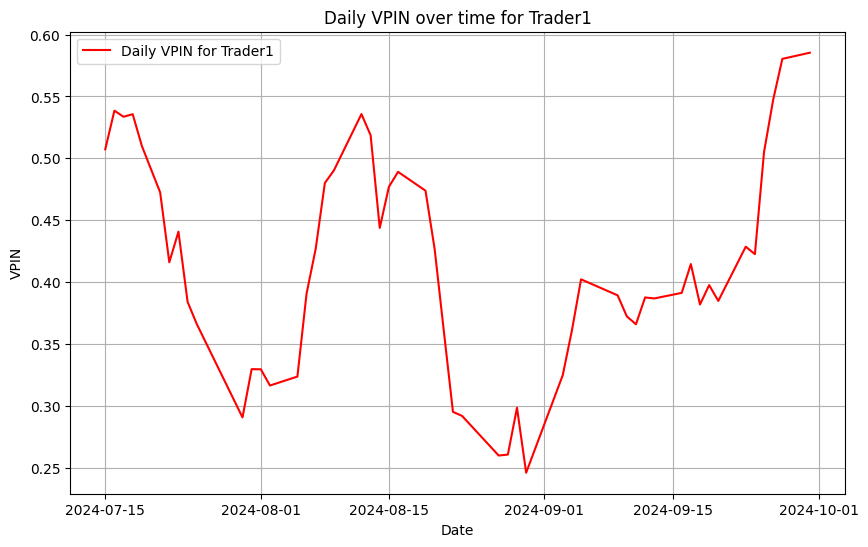

Trader1 Daily VPIN over time:
Sign        Buy Volume  Sell Volume  Order Imbalance      VPIN
let me tak                                                    
2024-07-15   451463500   1026204600        574741100  0.507252
2024-07-16    88374700    341888800        253514100  0.538506
2024-07-17    43968500    163130800        119162300  0.533593
2024-07-18    85572000    254352100        168780100  0.535644
2024-07-19    60936800    170712800        109776000  0.509983
2024-07-21           0            0                0  0.472437
2024-07-22    76565000    383104400        306539400  0.415955
2024-07-23    66471000    333576500        267105500  0.440719
2024-07-24   101823000    346037300        244214300  0.383929
2024-07-25   132585100    186433800         53848700  0.366074


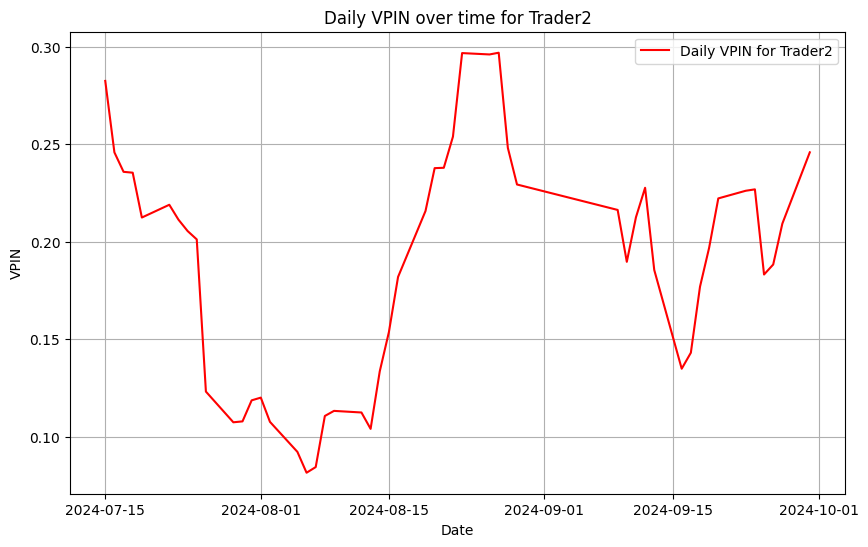

Trader2 Daily VPIN over time:
Sign        Buy Volume  Sell Volume  Order Imbalance      VPIN
let me tak                                                    
2024-07-15   161867000    281942300        120075300  0.282510
2024-07-16   173176400    216706500         43530100  0.245837
2024-07-17   117783000    158395000         40612000  0.235852
2024-07-18   143158900    161749300         18590400  0.235406
2024-07-19   167509200    258934000         91424800  0.212395
2024-07-22   253196700    333652500         80455800  0.218947
2024-07-23   139697100    192921700         53224600  0.211310
2024-07-24   134702500    109043800         25658700  0.205467
2024-07-25   232423600    275370600         42947000  0.201175
2024-07-26   129957900    195852000         65894100  0.123069


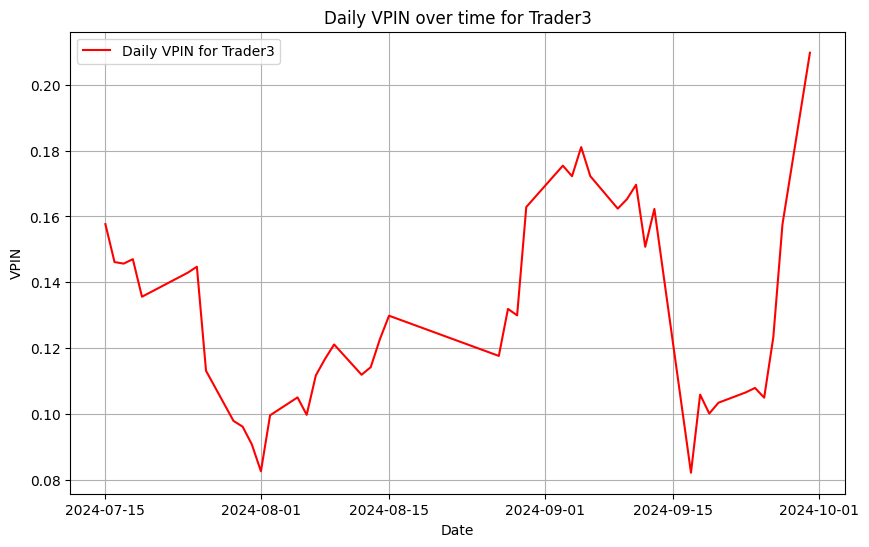

Trader3 Daily VPIN over time:
Sign        Buy Volume  Sell Volume  Order Imbalance      VPIN
let me tak                                                    
2024-07-15   245048000    156016000         89032000  0.157672
2024-07-16   271099800    380569000        109469200  0.146129
2024-07-17   595888000    652318000         56430000  0.145659
2024-07-18   225866000    294004000         68138000  0.147013
2024-07-19   273295100    368725000         95429900  0.135587
2024-07-24  1032696800    805486100        227210700  0.142895
2024-07-25   759270500    512686000        246584500  0.144709
2024-07-26   284908000    330393100         45485100  0.113074
2024-07-29   927671500    804830900        122840600  0.097847
2024-07-30   531571400    348343000        183228400  0.096088


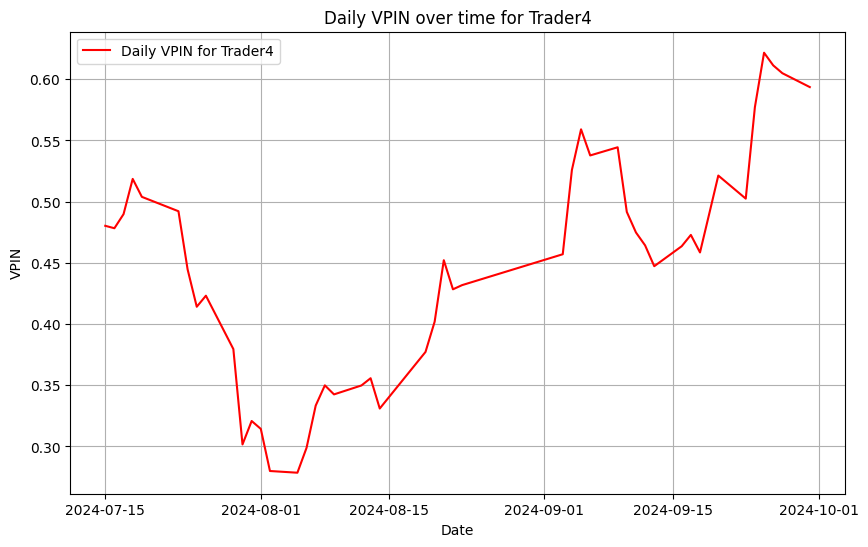

Trader4 Daily VPIN over time:
Sign        Buy Volume  Sell Volume  Order Imbalance      VPIN
let me tak                                                    
2024-07-15  1047774300   7739986200       6692211900  0.480270
2024-07-16  1868358700   4850186400       2981827700  0.478284
2024-07-17  1881872000   3349541600       1467669600  0.489807
2024-07-18  2397096200   5172360400       2775264200  0.518582
2024-07-19  1101954300   2341782700       1239828400  0.503919
2024-07-23  1083762200   3249432500       2165670300  0.492169
2024-07-24  3691792500   3936031800        244239300  0.444681
2024-07-25  2817084500   1674069900       1143014600  0.414149
2024-07-26  2847965400   1562670900       1285294500  0.423175
2024-07-29  4403139000   3389899400       1013239600  0.379583


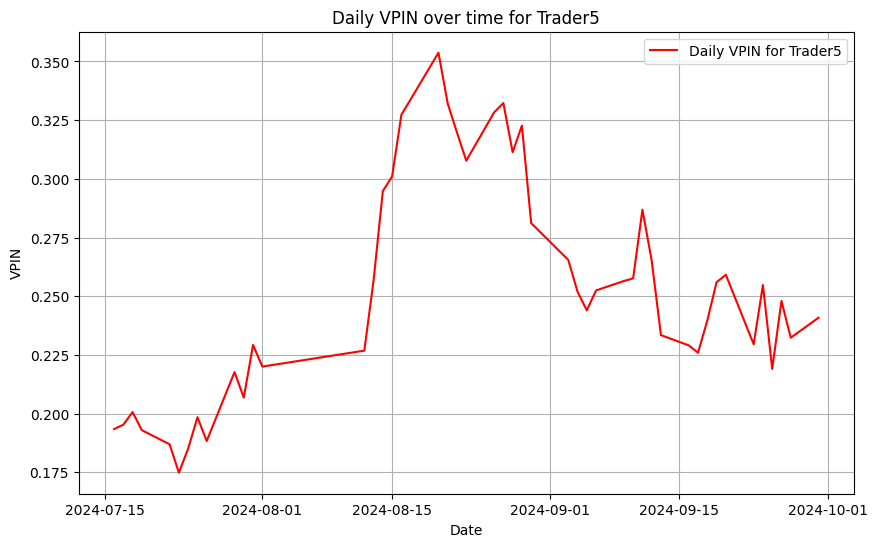

Trader5 Daily VPIN over time:
Sign        Buy Volume  Sell Volume  Order Imbalance      VPIN
let me tak                                                    
2024-07-16   238143000    487711800        249568800  0.193421
2024-07-17   526901000    707837000        180936000  0.195279
2024-07-18    30335300    173506000        143170700  0.200660
2024-07-19   159200000    134740000         24460000  0.192970
2024-07-22   387730000    255945000        131785000  0.186950
2024-07-23   361976400    380001300         18024900  0.174846
2024-07-24   296650000    627610500        330960500  0.185131
2024-07-25   432410500    611422000        179011500  0.198486
2024-07-26   201514000    260510300         58996300  0.188336
2024-07-29   143974000    534709000        390735000  0.217706


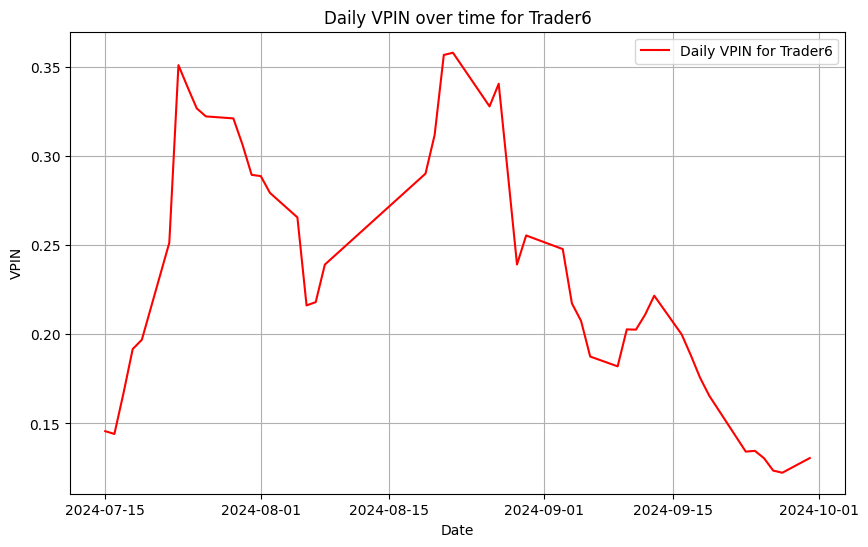

Trader6 Daily VPIN over time:
Sign        Buy Volume  Sell Volume  Order Imbalance      VPIN
let me tak                                                    
2024-07-15   222275000    307329100         85054100  0.145686
2024-07-16   313258000    124909400        188348600  0.144134
2024-07-17   382569000    180396000        202173000  0.167142
2024-07-18   421610000    126802000        294808000  0.191717
2024-07-19    80085000    257336000        177251000  0.196932
2024-07-22   412937000   1190422000        777485000  0.251290
2024-07-23  1459246000    570707500        888538500  0.350799
2024-07-24   372019000    475123000        103104000  0.338473
2024-07-25   937969800    913370100         24599700  0.326563
2024-07-26   141600000    193188000         51588000  0.322076


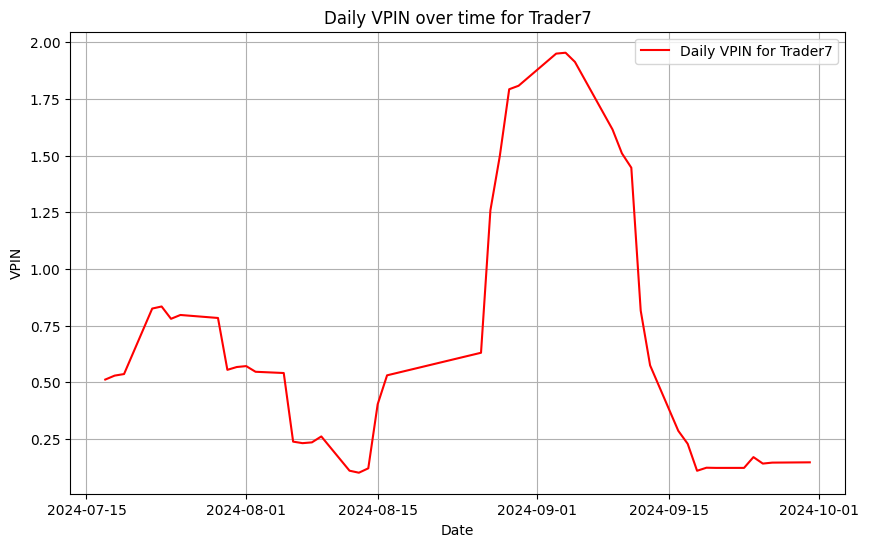

Trader7 Daily VPIN over time:
Sign        Buy Volume  Sell Volume  Order Imbalance      VPIN
let me tak                                                    
2024-07-17    59326000            0         59326000  0.512130
2024-07-18     2500000    154000000        151500000  0.529553
2024-07-19     1700000     37673000         35973000  0.536392
2024-07-22  1016983700   2605849500       1588865800  0.825403
2024-07-23    54000000    100969000         46969000  0.834517
2024-07-24           0            0                0  0.780190
2024-07-25    42000000    128951000         86951000  0.797061
2024-07-29   800000000     20655000        779345000  0.783833
2024-07-30     1540000     63315000         61775000  0.555045
2024-07-31     1500000    115350000        113850000  0.567433


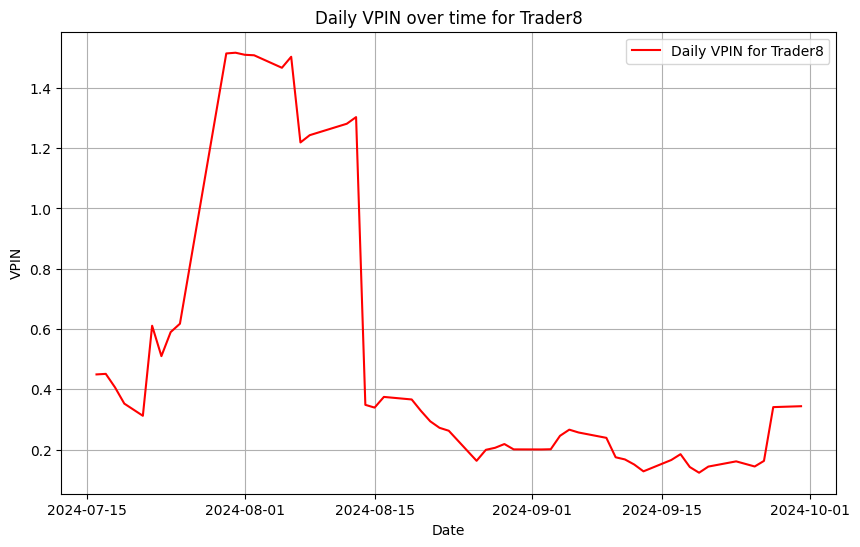

Trader8 Daily VPIN over time:
Sign        Buy Volume  Sell Volume  Order Imbalance      VPIN
let me tak                                                    
2024-07-16     1000000      4580000          3580000  0.449536
2024-07-17      661000      4085000          3424000  0.451368
2024-07-18           0      2548000          2548000  0.406372
2024-07-19           0     21773000         21773000  0.352649
2024-07-21           0            0                0  0.312290
2024-07-22     8709000     85510500         76801500  0.610993
2024-07-23           0      1030000          1030000  0.510217
2024-07-24           0     19750000         19750000  0.589926
2024-07-25           0      7500000          7500000  0.617733
2024-07-30   105723000    344522600        238799600  1.514295


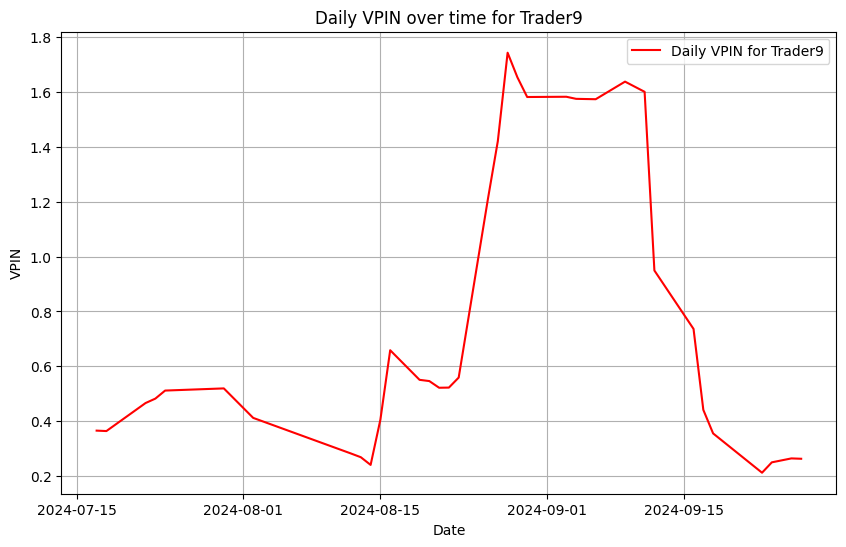

Trader9 Daily VPIN over time:
Sign        Buy Volume  Sell Volume  Order Imbalance      VPIN
let me tak                                                    
2024-07-17           0    142111400        142111400  0.365918
2024-07-18           0            0                0  0.364348
2024-07-22   334915000   1155455000        820540000  0.466389
2024-07-23           0    133970000        133970000  0.482490
2024-07-24   250000000            0        250000000  0.511832
2024-07-30           0     70735000         70735000  0.519718
2024-08-02    49000000     44820000          4180000  0.412286
2024-08-12   300000000     17000000        283000000  0.282488
2024-08-13           0     50000000         50000000  0.268998
2024-08-14           0     32000000         32000000  0.241013


In [187]:
import matplotlib.pyplot as plt
import pandas as pd

# Set the rolling window size
n = 10  # for 10-day rolling VPIN

# Loop through each trader to calculate daily VPIN
for trader in df['Trader'].unique():
    tmp_df = df[df["Trader"] == trader]

    # Step 1: Aggregate daily buy and sell volumes based on the Sign
    daily_volume = tmp_df.groupby([tmp_df['let me tak'].dt.date, 'Sign'])['Market Traded Vol (USD)'].sum().unstack(fill_value=0)
    daily_volume = daily_volume.rename(columns={1: 'Buy Volume', -1: 'Sell Volume'})

    # Step 2: Calculate daily order imbalance (OI) as the absolute difference between buy and sell volumes
    daily_volume['Order Imbalance'] = abs(daily_volume['Buy Volume'] - daily_volume['Sell Volume'])

    # Step 3: Calculate daily VPIN using a rolling 50-day window
    mean_daily_volume = daily_volume[['Buy Volume', 'Sell Volume']].sum(axis=1).mean()  # mean of total daily volume
    daily_volume['VPIN'] = daily_volume['Order Imbalance'].rolling(window=n).sum() / (n * mean_daily_volume)

    # Step 4: Plot the daily VPIN over time
    plt.figure(figsize=(10, 6))
    plt.plot(daily_volume.index, daily_volume['VPIN'], label=f'Daily VPIN for {trader}', color='red', linewidth=1.5)
    plt.xlabel('Date')
    plt.ylabel('VPIN')
    plt.title(f'Daily VPIN over time for {trader}')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Output the calculated daily VPIN values
    print(f"{trader} Daily VPIN over time:")
    print(daily_volume[['Buy Volume', 'Sell Volume', 'Order Imbalance', 'VPIN']].dropna().head(10))